In [ ]:
# Python Pandas Data Exploration Project

## Objective
This project performs exploratory data analysis (EDA) on a real-world dataset 
downloaded from Kaggle (~10K–50K rows).

The project includes:
- Data loading with proper data types
- Dataset exploration
- Missing value & duplicate analysis
- Filtering (SQL WHERE equivalent)
- Sorting & Ranking (SQL ORDER BY equivalent)
- Grouping & Aggregation (SQL GROUP BY equivalent)
- Creating calculated columns
- Data visualization
- Generating business insights


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [5]:
import os
os.getcwd()





'C:\\Users\\Vedika Pingat'

In [6]:
## Load Dataset with Proper Data Types
#We load the dataset and optimize memory using appropriate data types.
import os
print(os.path.exists("C:/Users/Vedika Pingat/Downloads/ecommerce/data.csv"))


True


In [7]:
import pandas as pd

# Define file path
file_path = "C:/Users/Vedika Pingat/Downloads/ecommerce/data.csv"

# Load dataset with proper encoding
df = pd.read_csv(file_path, encoding="latin1", low_memory=False)

# Display first 5 rows
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
#columns
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
#Adjust column names
print(df.columns.tolist())


['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [10]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

df.columns


Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [11]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
df["country"] = df["country"].astype("category")
df["description"] = df["description"].astype("category")


In [ ]:
## Basic Dataset Exploration


In [12]:
df.shape


(541909, 8)

In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    541909 non-null  str           
 1   stockcode    541909 non-null  str           
 2   description  540455 non-null  category      
 3   quantity     541909 non-null  int64         
 4   invoicedate  541909 non-null  datetime64[us]
 5   unitprice    541909 non-null  float64       
 6   customerid   406829 non-null  float64       
 7   country      541909 non-null  category      
dtypes: category(2), datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 26.4 MB


In [14]:
df.describe(include="all")


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [15]:
df.head()


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
df.tail()


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [17]:
## Missing Value Analysis in each column
df.isnull().sum()


invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [18]:
df.dropna(inplace=True)


In [19]:
df.isnull().sum()
#confirming

invoiceno      0
stockcode      0
description    0
quantity       0
invoicedate    0
unitprice      0
customerid     0
country        0
dtype: int64

In [20]:
## Duplicate Record Analysis
df.duplicated().sum()


np.int64(5225)

In [21]:
df.drop_duplicates(inplace=True)


In [22]:
df.duplicated().sum()
#confirming

np.int64(0)

In [23]:
## Data Filtering (Equivalent to SQL WHERE)
#creating sales 
df["sales"] = df["quantity"] * df["unitprice"]

df.head()


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [24]:
high_sales = df[df["sales"] > 500]
high_sales.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,sales
178,536387,79321,CHILLI LIGHTS,192,2010-12-01 09:58:00,3.82,16029.0,United Kingdom,733.44
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,647.04
180,536387,22779,WOODEN OWLS LIGHT GARLAND,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,647.04
181,536387,22466,FAIRY TALE COTTAGE NIGHTLIGHT,432,2010-12-01 09:58:00,1.45,16029.0,United Kingdom,626.40
182,536387,21731,RED TOADSTOOL LED NIGHT LIGHT,432,2010-12-01 09:58:00,1.25,16029.0,United Kingdom,540.00


In [25]:
## Sorting and Ranking Data
sorted_data = df.sort_values(by="sales", ascending=False)
sorted_data.head()


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72


In [26]:
df["Sales_Rank"] = df["sales"].rank(
    method="dense",
    ascending=False
)


In [27]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'sales', 'Sales_Rank'],
      dtype='str')

In [28]:
## Grouping and Aggregation
country_sales = df.groupby("country")["sales"].sum().sort_values(ascending=False)

country_sales.head()

#insights :#total sales by a country


country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Name: sales, dtype: float64

In [29]:
top_products = (
    df.groupby("description")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products
#insights:top selling products

description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: sales, dtype: float64

In [30]:
#creating 5 columns
# Revenue per Unit (this is basically unitprice)
df["revenue_per_unit"] = df["unitprice"]

#  Total Sales (already created above, but keeping structured)
df["total_sales"] = df["quantity"] * df["unitprice"]

#  Year from Invoice Date
df["year"] = pd.to_datetime(df["invoicedate"]).dt.year

#  Month from Invoice Date
df["month"] = pd.to_datetime(df["invoicedate"]).dt.month

#  High Value Order Flag
df["high_value_order"] = np.where(df["total_sales"] > 1000, 1, 0)


In [31]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'sales', 'Sales_Rank',
       'revenue_per_unit', 'total_sales', 'year', 'month', 'high_value_order'],
      dtype='str')

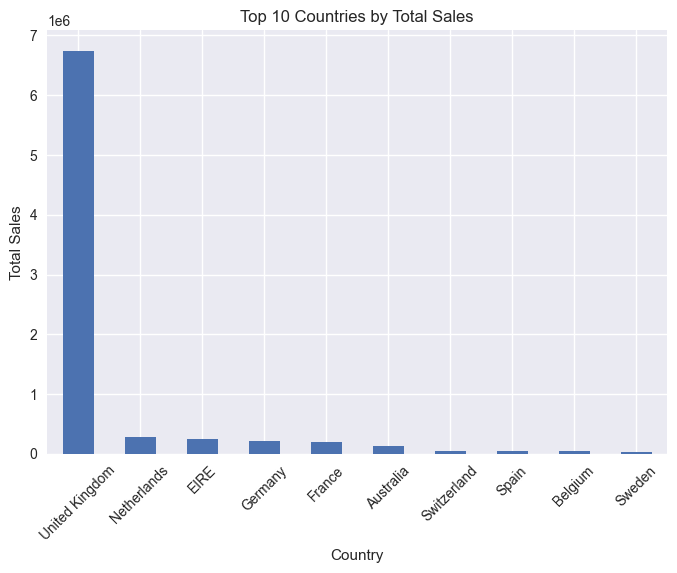

In [32]:
country_sales = (
    df.groupby("country")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure()
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


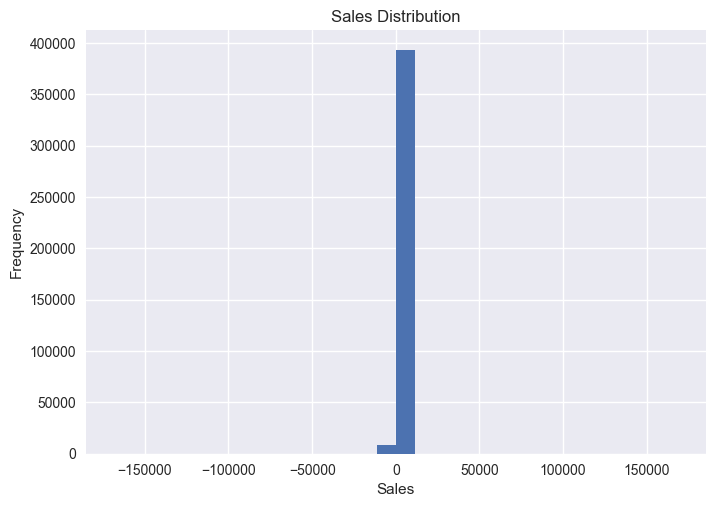

In [33]:
#sales distribution
plt.figure()
plt.hist(df["sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


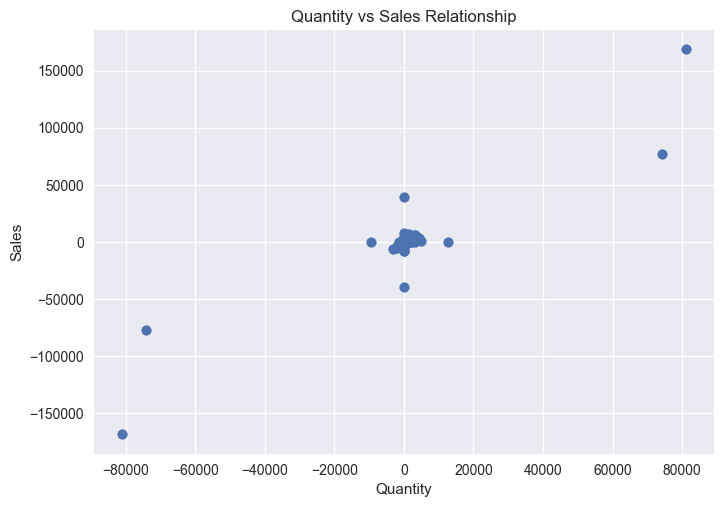

In [34]:
#quantity vs sales relation
plt.figure()
plt.scatter(df["quantity"], df["sales"])
plt.title("Quantity vs Sales Relationship")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()


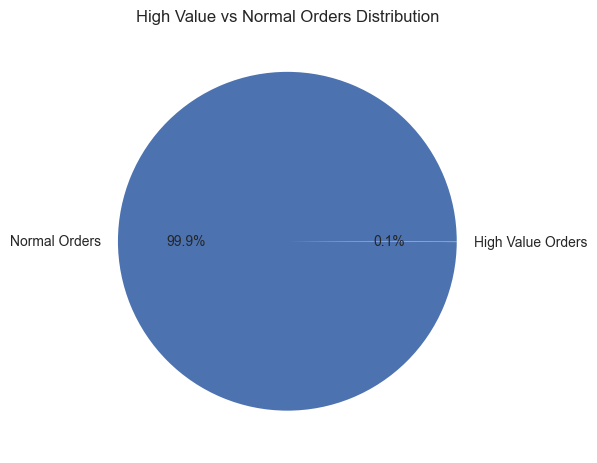

In [35]:
order_distribution = df["high_value_order"].value_counts()

plt.figure()
plt.pie(order_distribution, labels=["Normal Orders", "High Value Orders"], autopct='%1.1f%%')
plt.title("High Value vs Normal Orders Distribution")
plt.show()



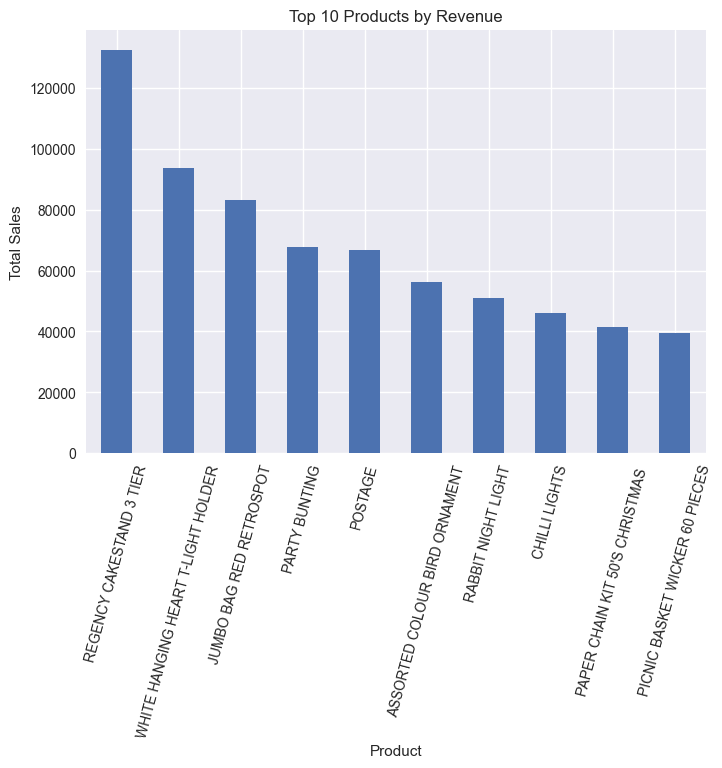

In [36]:
# product revenue
top_products = df.groupby("description")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.show()


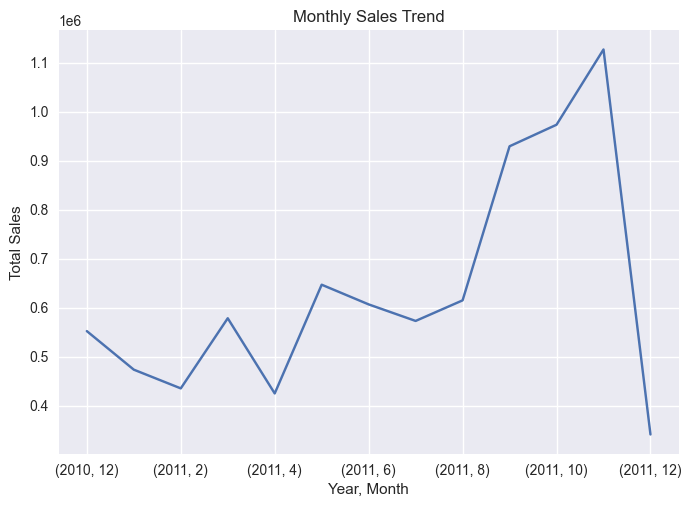

In [37]:
# Group sales by year and month
monthly_sales = df.groupby(["year", "month"])["sales"].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Year, Month")
plt.ylabel("Total Sales")
plt.show()


In [ ]:
1.Top 10 Countries by Sales:
few countries bring most of the sales, which means the business depends more on these markets.
    
2. Sales Distribution (Histogram):
Most orders have small sales amounts, and only a few orders have very high sales.

3.Quantity vs Sales (Scatter Plot):
When customers buy more quantity, the total sales amount also increases.

4.High Value vs Normal Orders (Pie Chart):
High-value orders are fewer, but they help increase overall revenue.

️5.Top 10 Products by Revenue:
Some products earn much more revenue than others and are very important for the business.

️6.Monthly Sales Trend (Line Graph):
Sales change over time, showing busy months and slow months in the business.

In [39]:
df.to_csv("cleaned_data.csv", index=False)


In [40]:
import os
print(os.path.exists("cleaned_data.csv"))


True
